# Exercise 2: Manifold Learning

**Note**: Please insert the names of all participating students:

1.
2.
3.
4.
5.

In [1]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs5450.git'
    os.chdir('cs5450')

Cloning into 'cs5450'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 130 (delta 40), reused 29 (delta 13), pack-reused 61 (from 1)
Receiving objects: 100% (130/130), 28.16 MiB | 19.59 MiB/s, done.
Resolving deltas: 100% (67/67), done.


## Exercise 2.1: Multi-dimensional Scaling (MDS)

In this exercise, we will implement Multi-dimensional Scaling.

Implement the missing parts below. When done correctly, your code should do the following:
1. Generate a swiss roll dataset.
2. Compute the squared euclidean distances between samples.
3. Compute the gram matrix from squared distances and the centering matrix.
4. Sort the eigenvalues and corresponding eigenvectors of the gram matrix.
5. Calculate the MDS data representation with reduced dimensions.
6. Show the lower-dimensional representation of the data.

In case you are struggeling with the task, here are some helpful tips and hints:
1. Useful functions: [`make_swiss_roll`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_swiss_roll.html), [`pdist`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html), [`squareform`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.squareform.html), [`numpy.eye`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.eye.html), [`numpy.ones`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html), [`numpy.linalg.eig`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eig.html), [`numpy.argsort`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argsort.html), [`numpy.sqrt`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.sqrt.html), [`numpy.diag`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.diag.html), [`Axes.scatter`](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.axes.Axes.scatter.html#matplotlib.axes.Axes.scatter), [`Axes3D.scatter`](https://matplotlib.org/3.1.1/api/_as_gen/mpl_toolkits.mplot3d.axes3d.Axes3D.html#mpl_toolkits.mplot3d.axes3d.Axes3D.scatter)

2. Additional references: [Color maps for matplotlib](https://matplotlib.org/examples/color/colormaps_reference.html)

Note: Don't use the MDS implementation provided by the sklearn package here.

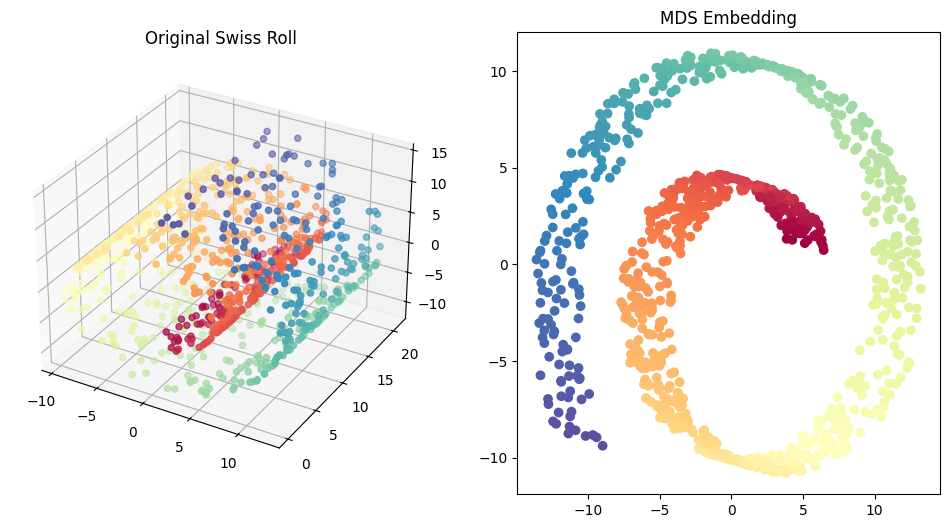

In [7]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import make_swiss_roll
%matplotlib inline


## Define variables
# TODO n_samples : number of random samples (observations)
n_samples = 1000

# n_dims : number of dimensions of the embedding
n_dims = 2

## Compute and visualize the embedding using MDS

# TODO generate data (make_swiss_roll)
# Returns data (positions) and color (univariate position on the manifold)
data, color = make_swiss_roll(n_samples=n_samples)

# TODO compute euclidean distance vector (pdist)
# pdist computes pairwise distances between observations in n-dimensional space
distances_vec = pdist(data, metric='euclidean')

# TODO reshape into distance matrix (squareform)
# Converts the vector form to a square matrix D
distances = squareform(distances_vec)

# TODO square the distances inside the matrix
distances_squared = distances ** 2

# TODO calculate the centering matrix H (c.f. page 15, Eq roughly below 1.19 in script)
# H = I - (1/p) * 1 * 1^T
p = n_samples
I = np.eye(p)
# np.ones((p, p)) creates the 1*1^T matrix
centering = I - (1/p) * np.ones((p, p))

# TODO compute the gram matrix B (c.f. page 15)
# B = -1/2 * H * D^2 * H
gram = -0.5 * centering.dot(distances_squared).dot(centering)

# TODO compute its eigenvectors and eigenvalues (eig)
eig_values, eig_vectors = np.linalg.eig(gram)

# TODO sort the eigenvalues and its corresponding eigenvectors (descending!)
# argsort gives indices that sort array. [::-1] reverses it to descending.
permutation = np.argsort(eig_values)[::-1]
eig_vectors = eig_vectors[:, permutation]
eig_values = eig_values[permutation]

# TODO calculate the square root of the eigenvalues
# We only need the top 'n_dims' eigenvalues.
epsilon = 0.001
# Taking the real part is a safety measure against numerical noise creating complex numbers
eig_values_root = np.sqrt(np.maximum(eig_values[:n_dims], epsilon))

# TODO reduce dimensions (c.f. equation 1.20)
data_mds = eig_vectors[:, :n_dims].dot(np.diag(eig_values_root))

# TODO visualize
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title("Original Swiss Roll")

ax = fig.add_subplot(122)
ax.scatter(data_mds[:, 0], data_mds[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title("MDS Embedding")
plt.show()

## Exercise 2.2: Isomap

In this exercise, we will be implementing the Isomap algorithm.

You can use the MDS implementation from sklearn within your Isomap implementation.

Implement the missing parts below. When done correctly, your code should do the following:
1. Generate a swiss roll dataset.
2. Compute the euclidean distances between samples.
3. Sort the neighbors of each sample by distance.
4. Keep the closest k neighbors of each sample and set all other distances to infinity or NaN or zero to mark them as not-connected.
5. Calculate all shortest paths between pairs of samples (representing geodesic distances on the manifold).
6. Calculate the MDS data representation with reduced dimensions on the geodesic distances.
7. Show the lower-dimensional representation of the data.

In case you are struggeling with the task, here are some helpful tips and hints:
1. Useful functions:[`csgraph_from_dense`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.csgraph_from_dense.html), [`shortest_path`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.shortest_path.html#scipy.sparse.csgraph.shortest_path), [`MDS`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html)
2. Make sure to use MDS with `dissimilarity='precomputed'` so that it takes a distance matrix as input instead of a matrix of sample coordinates.

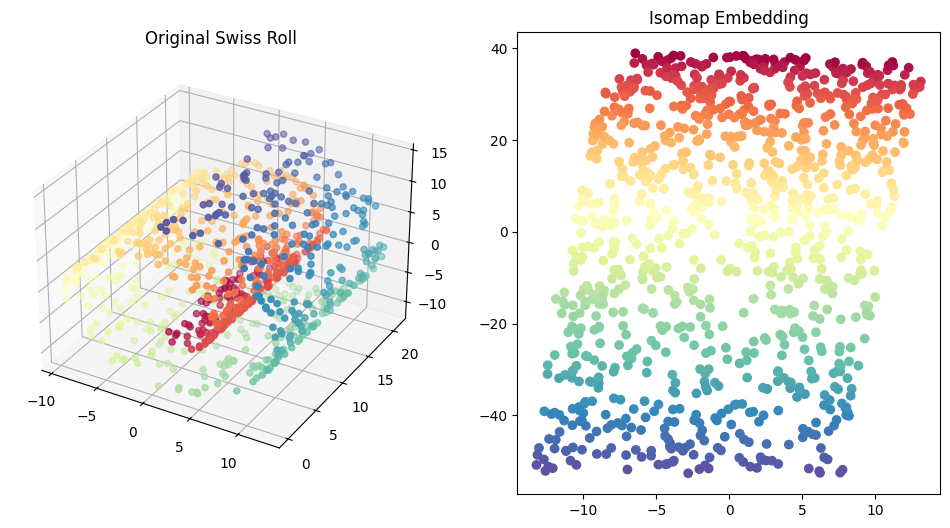

In [4]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import shortest_path
from sklearn.manifold import MDS
from sklearn.datasets import make_swiss_roll
%matplotlib inline
## Define variables
n_samples = 1000
n_dims = 2
n_neighbors = 12

## Compute and visualize
data, color = make_swiss_roll(n_samples=n_samples)

# TODO compute euclidean distance vector (pdist)
distances_vec = pdist(data, metric='euclidean')

# TODO reshape into distance matrix (squareform)
distances = squareform(distances_vec)

# TODO find the nearest neighbor-indices (argsort)
# We sort along axis 1 to find neighbors for each row
permutation = np.argsort(distances, axis=1)

# TODO create the local distance matrix
distances_local = np.zeros_like(distances)

for i in range(n_samples):
   # TODO: write the K-NNs (of the i-th row) distances
   # We take indices 1 to n_neighbors+1 because index 0 is the point itself (dist=0)
   indices = permutation[i, 1:n_neighbors+1]
   distances_local[i, indices] = distances[i, indices]

# enforce distances_local to be symmetric (Graph must be undirected)
distances_local_transposed = distances_local.T
mask = (distances_local == 0) & (distances_local_transposed != 0)
distances_local[mask] = distances_local_transposed[mask]

# TODO compute shortest paths
# This computes the Geodesic distances
distances_geodesic = shortest_path(distances_local, method='D', directed=False)
assert not np.any(np.isinf(distances_geodesic)), 'Error: manifold is fragmented.'

# TODO classical multidimensional scaling (MDS)
# We use dissimilarity='precomputed' because we are passing a distance matrix, not coordinates
embedding = MDS(n_components=n_dims, dissimilarity='precomputed', random_state=42)
data_isomap = embedding.fit_transform(distances_geodesic)

# TODO visualize
fig = plt.figure(figsize = (12,6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title("Original Swiss Roll")

ax = fig.add_subplot(122)
ax.scatter(data_isomap[:, 0], data_isomap[:, 1], c=color, cmap=plt.cm.Spectral)
ax.set_title("Isomap Embedding")
plt.show()

## Exercise 2.3: Comprehension Questions

Answer the following comprehension questions either with right or wrong and briefly explain your decision:

1. A manifold is a topological space that locally resembles Euclidean space near each point, e.g. a sphere.

T

2. The features found by classical MDS are equivalent to the ones computed by ICA.

F

3. Isomap replaces the Euclidean distance measure used by MDS with geodesic distances.

T

4. Local Linear Embedding (LLE) seeks a lower-dimensional projection of the data trying to preserve the distances within a local neighborhood.

T

5. Unlike MDS, LLE uses global properties of the manifold to find an embedding.

F

6. $n+1$ non-collinear points of two distinct classes are always linearly separable in $\mathbb{R}^n$.

T

7. The reason that the kernel trick can be applied is that the observations only show up in pairs of inner products.

T

8. To apply the kernel trick, the function $\boldsymbol{\Phi} \left( \vec{x} \right)$ must be explicitly known.

F

9. The function $\boldsymbol{\Phi} \left( \vec{x} \right) = \boldsymbol{\Phi} \left( \left[x_1, x_2 \right] \right) = \left[ x_1^2, \sqrt{2} x_1 x_2, x_2^2\right]$ is a function of the kernel $K \left( \vec{x}, \vec{y} \right) = \langle \vec{x}, \vec{y}\rangle^2$. This function is unique.

F